In [56]:
!pip install matplotlib
!pip install seaborn
!pip install openpyxl
!pip install scikit-learn
!pip install statsmodels


In [57]:
import os 
os.chdir('C:/Users/HP/Desktop/customer-churn')


In [2]:
# importing required libraries
import sklearn
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf

In [59]:
df = pd.read_excel("customer_churn_large_dataset.xlsx")
df.head()

,CustomerID,Name,Age,Gender,Location,Subscription_Length_Months,Monthly_Bill,Total_Usage_GB,Churn
0,1,Customer_1,63,Male,Los Angeles,17,73.36,236,0
1,2,Customer_2,62,Female,New York,1,48.76,172,0
2,3,Customer_3,24,Female,Los Angeles,5,85.47,460,0
3,4,Customer_4,36,Female,Miami,3,97.94,297,1
4,5,Customer_5,46,Female,Miami,19,58.14,266,0


In [60]:
df.drop(['Name'], axis=1, inplace=True)

In [61]:

df.drop(['Location'], axis=1, inplace=True)

In [62]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Subscription_Length_Months',
       'Monthly_Bill', 'Total_Usage_GB', 'Churn'],
      dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CustomerID                  100000 non-null  int64  
 1   Age                         100000 non-null  int64  
 2   Gender                      100000 non-null  object 
 3   Subscription_Length_Months  100000 non-null  int64  
 4   Monthly_Bill                100000 non-null  float64
 5   Total_Usage_GB              100000 non-null  int64  
 6   Churn                       100000 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 5.3+ MB


**All variables has correct data type.**

In [64]:
df.isna().sum()

CustomerID                    0
Age                           0
Gender                        0
Subscription_Length_Months    0
Monthly_Bill                  0
Total_Usage_GB                0
Churn                         0
dtype: int64

**There is no null value in any of variable.**

In [65]:
df.duplicated().sum()

np.int64(0)

**There is no duplicate record in datset.**

In [66]:
# Statistical summary of numerical variables

df.describe()

,CustomerID,Age,Subscription_Length_Months,Monthly_Bill,Total_Usage_GB,Churn
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,44.027020,12.490100,65.053197,274.393650,0.497790
std,28867.657797,15.280283,6.926461,20.230696,130.463063,0.499998
min,1.000000,18.000000,1.000000,30.000000,50.000000,0.000000
25%,25000.750000,31.000000,6.000000,47.540000,161.000000,0.000000
50%,50000.500000,44.000000,12.000000,65.010000,274.000000,0.000000
75%,75000.250000,57.000000,19.000000,82.640000,387.000000,1.000000
max,100000.000000,70.000000,24.000000,100.000000,500.000000,1.000000


### `Age` 

* **The average age of the customers is  44 years approximately.**


* **The ages also vary widely ranging from 18 to 70 years while the majority of customers fall within the range of 31 to 57 years.**


* **The standard deviation for ages is 18 years old .**


### `Subscription_Length_Months` 

* **The average subscription length for a customer is 12.5 months .**


* **Subscription lengths vary between 1 and 24 months.**



* **The standard deviation is approximately 6.9 months, indicating variation in subscription lengths.**


### `Monthly_Bill`

* **Customers pay an average monthly bill of roughly 65 dollar.**


* **Monthly bills range from 30  to 100 Dollar .**


* **The majority of customers pay between approximately 47.50 Dollar to 82.64 Dollar per month.**


* **Monthly bill amounts have a standard deviation of about $20.23, showing variability.**


### `Total_Usage_GB`

* **The average total usage of customers is about 274.4 GB.**


* **Total usage varies between 50 to 500 GB .**


* **Most customers have total usage between 161 GB and 387 GB.**


* **Total usage has a standard deviation of approximately 130.46 GB.**

### `Churn`

* **About half of the customers have churned (Churn value = 1), while the other half haven't (Churn value = 0).**


* **This is represented by a mean churn rate of approximately 0.5.**


* **Churn values are binary (0 or 1), indicating whether a customer has churned or not.**


* **Churn rate is evenly distributed due to a mean close to 0.5.**

In [67]:
# summary of categoical variables

df.describe(include=['object'])

,Gender
count,100000
unique,2
top,Female
freq,50216


In [68]:
df["Gender"].value_counts()

Gender
Female    50216
Male      49784
Name: count, dtype: int64

In [69]:
df['Gender']=df["Gender"].map({'Male':0,'Female':1})

In [70]:
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Subscription_Length_Months',
       'Monthly_Bill', 'Total_Usage_GB', 'Churn'],
      dtype='object')


In [71]:
df_numeric = df.select_dtypes(include=['number']).columns

df.select_dtypes(include=['number'])
corr_matrix = df[df_numeric].corr()
corr_matrix



,CustomerID,Age,Gender,Subscription_Length_Months,Monthly_Bill,Total_Usage_GB,Churn
CustomerID,1.000000,-0.001085,0.000131,0.005444,0.001265,-0.004025,-0.004586
Age,-0.001085,1.000000,-0.000832,0.003382,0.001110,0.001927,0.001559
Gender,0.000131,-0.000832,1.000000,-0.000320,-0.002239,0.001385,-0.002121
Subscription_Length_Months,0.005444,0.003382,-0.000320,1.000000,-0.005294,-0.002203,0.002328
Monthly_Bill,0.001265,0.001110,-0.002239,-0.005294,1.000000,0.003187,-0.000211
Total_Usage_GB,-0.004025,0.001927,0.001385,-0.002203,0.003187,1.000000,-0.002842
Churn,-0.004586,0.001559,-0.002121,0.002328,-0.000211,-0.002842,1.000000


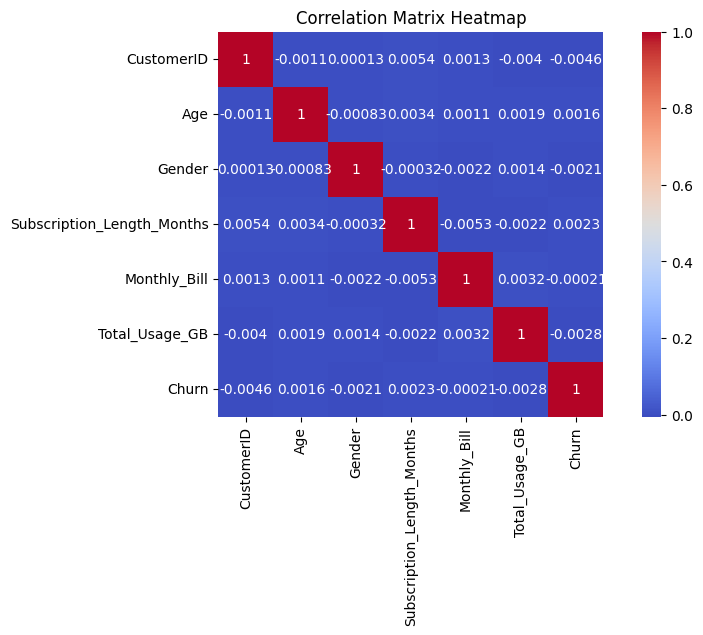

In [72]:

plt.figure(figsize=(10,5)) #(width,height)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()



### `Age and Total Usage`

* **Age and total usage in GB have a very low positive correlation of around 0.0019.**

### `Age and Churn`

* **Age and churn have a very low positive correlation of about 0.0016.This means that there is almost no linear relationship between a customer's age and their likelihood to churn means customer's age is not a good predictor of whether they will churn.**


### `Subscription Length and Monthly Bill`

* **Subscription length and monthly bill amount have a very low negative correlation of approximately -0.0053.**


### `Monthly Bill and Churn`

* **Monthly bill amount and churn have an extremely low negative correlation of approximately -0.0002.**
* **This suggests that there is no linear relationship between monthly bill amount and churn behavior.** 

### `Total Usage and Churn`

* **Total usage and churn have a very low negative correlation of about -0.0028.There is almost no linear relationship between a customer's data usage and their likelihood to churn.**

In [73]:
# Check for typos & suspicious values and rechecking dataset 

for column in df.columns:
    unique_values = df[column].unique()
    print(f"Unique values in '{column}': {unique_values}")
    print()

missing_values = df.isnull().sum()
data_types = df.dtypes

print('-'*50)
print("Missing values:")
print(missing_values)
print()

x = df.duplicated().sum()
print('-'*50)
print("Duplicate values:", x)
print()


y = df.shape
print('-'*50)
print("Shape of Dataset:", y)
print()

z = df.columns
print('-'*50)
print("Columns of Datset:", z)
print()

print('-'*50)
print("\nData types:")
print(data_types)
print()

Unique values in 'CustomerID': [     1      2      3 ...  99998  99999 100000]

Unique values in 'Age': [63 62 24 36 46 67 30 20 53 50 44 34 28 42 55 43 31 41 58 64 70 18 25 27
 66 29 60 26 45 19 37 49 38 57 47 48 40 21 33 51 35 69 61 52 39 56 59 65
 22 54 68 32 23]

Unique values in 'Gender': [0 1]

Unique values in 'Subscription_Length_Months': [17  1  5  3 19 15 10 12 20 13  8 23  2  4 18  9 14 16  6  7 24 22 11 21]

Unique values in 'Monthly_Bill': [73.36 48.76 85.47 ... 75.21 41.98 83.55]

Unique values in 'Total_Usage_GB': [236 172 460 297 266 456 269 396 150 383 442 295 148 239 233 231 198 354
 429 243 270 389 226 393  89 183 135 185 151 115 194 278 423 202 495 162
 101 294 122 305 212 220 253 411 447 218 221 166  64  67 391 232 298 334
 326 459 371 299 376 214 329  50 444 113  76 134 184 319 235  85 332  73
 369 308 446 321  83 114 296 102 215 169 225 140  84 463 402 468 375 366
 404 471 204 320 178 149 361 304 281 177 117 137 322 427 403 237 439 336
 344 288 257 196 365 419 11

**The dataset has been cleaned and no suspicious values or typos have been found.**

# `CHECKING FOR OUTLIERS'

It is important to find and remove unusual or extreme data points, also known as outliers. Outliers can affect the model's understanding of the data and lead to wrong predictions. By identifying and removing outliers, the model becomes more accurate and reliable, and can better capture the actual patterns in the data.

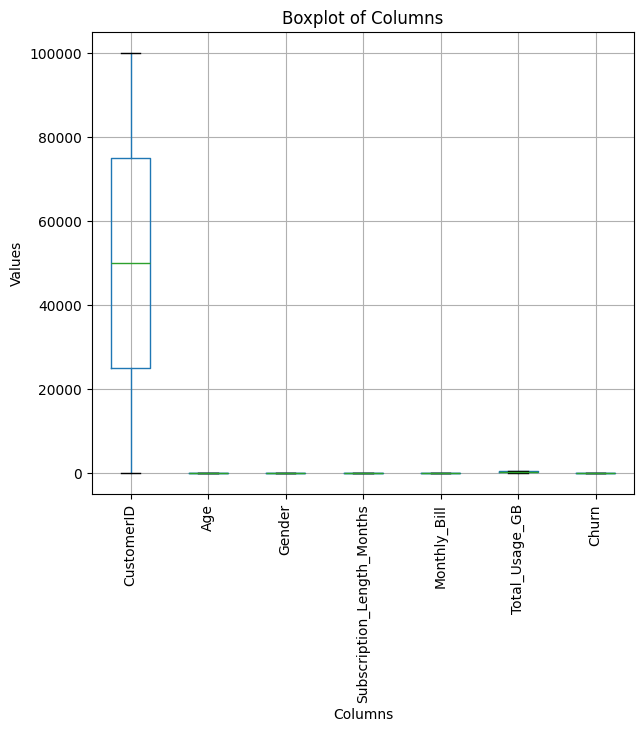

In [74]:
# Adjust figure size based on the number of columns
num_columns = len(df.columns)
fig, ax = plt.subplots(figsize=(10, 6))
if num_columns > 16:
    fig.set_size_inches(10, num_columns * 0.6)
else:
    fig.set_size_inches(num_columns, 6)

# Create a boxplot for each column
df.boxplot(ax=ax)

# Set the title and labels
plt.title("Boxplot of Columns")
plt.xlabel("Columns")
plt.ylabel("Values")

# Rotate the x-axis labels for better readability (optional)
plt.xticks(rotation=90)

# Show the plot
plt.show()

**There is no outlier present in any of the variable.**

In [75]:
# Make a copy of cleaned data

df_cleaned = df.copy()

In [76]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index([], dtype='object')

In [77]:
df.head()

,CustomerID,Age,Gender,Subscription_Length_Months,Monthly_Bill,Total_Usage_GB,Churn
0,1,63,0,17,73.36,236,0
1,2,62,1,1,48.76,172,0
2,3,24,1,5,85.47,460,0
3,4,36,1,3,97.94,297,1
4,5,46,1,19,58.14,266,0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CustomerID                  100000 non-null  int64  
 1   Age                         100000 non-null  int64  
 2   Gender                      100000 non-null  int64  
 3   Subscription_Length_Months  100000 non-null  int64  
 4   Monthly_Bill                100000 non-null  float64
 5   Total_Usage_GB              100000 non-null  int64  
 6   Churn                       100000 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 5.3 MB


**Data types of all variables is fine.**

In [79]:
df.shape

(100000, 7)

In [ ]:
# Select appropriate bin size using sturges_rule

import math

def sturges_rule(num_data_points):
    k = 1 + math.log2(num_data_points)
    return int(k)

# Example usage
num_data_points = 100000
bins = sturges_rule(num_data_points)
print("Number of bins according to Sturges' Rule:", bins)

Number of bins according to Sturges' Rule: 17


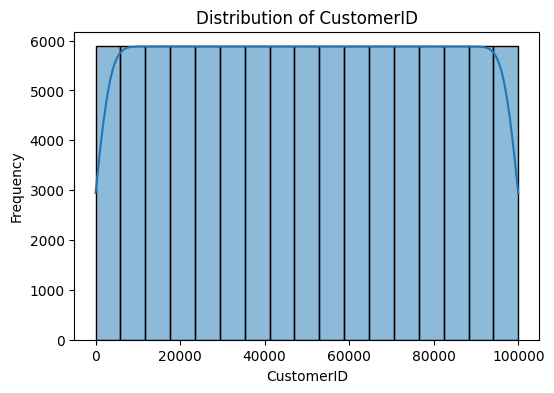

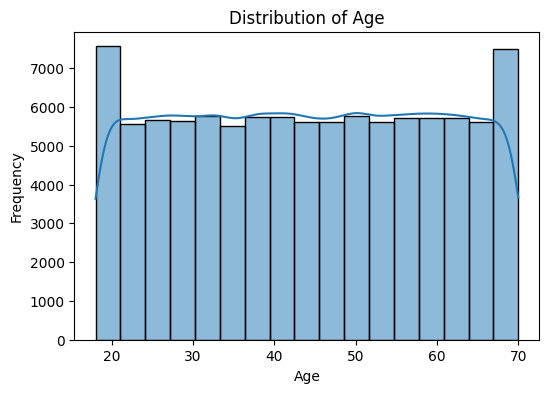

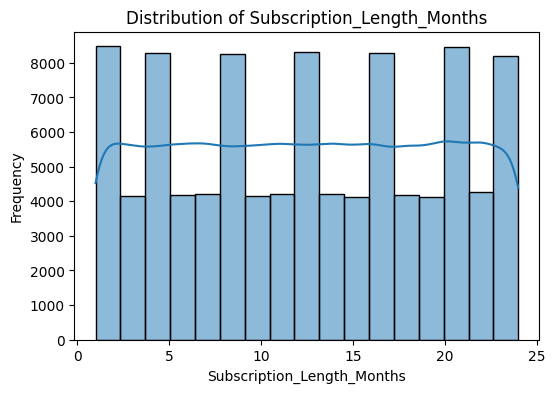

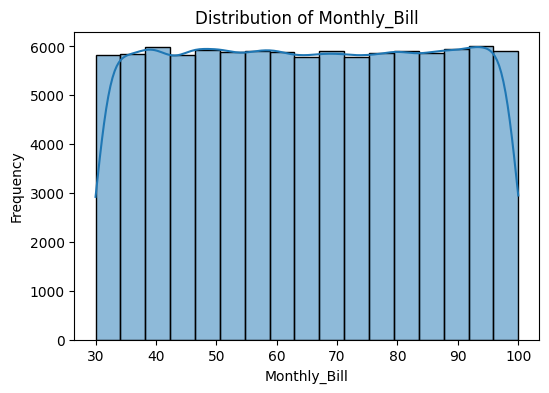

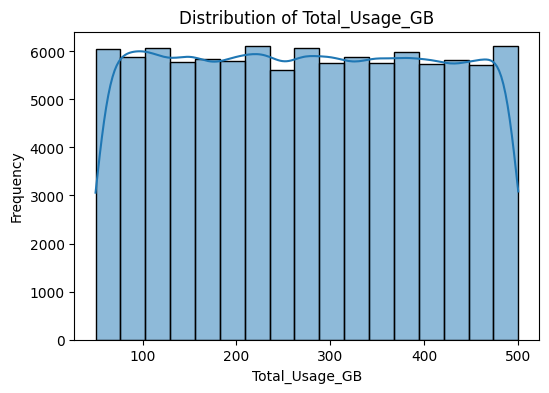

In [ ]:
# check distribution of all continuous variables
continuous_vars = df.select_dtypes(include=['float64', 'int64']).columns

# Exclude binary variables from the list
binary_vars = [var for var in continuous_vars if df[var].nunique() == 2]

# Exclude binary variables from the continuous variables
continuous_vars = [var for var in continuous_vars if var not in binary_vars]

# Plot the distribution of each continuous variable
for var in continuous_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=var, bins=17, kde=True)
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {var}')
    plt.show()

In [ ]:
# check skewness of all continuous variables
df[continuous_vars].skew()

CustomerID                   -1.064188e-16
Age                          -2.688581e-03
Subscription_Length_Months   -1.655482e-03
Monthly_Bill                 -3.257340e-04
Total_Usage_GB                7.113380e-03
dtype: float64

**All variables are approx normally distributed.**

# `Checking colinearity `

* In machine learning, it is important to check if there are variables that are highly correlated with each other. If there are, then we should remove one of them to improve the stability and interpretability of the model.


* Highly correlated variables are redundant, meaning that they provide the same information. This can cause the model to give too much importance to one variable, leading to overfitting. Overfitting is when the model learns the training data too well and does not generalize well to new data.


* By removing highly correlated variables, we can make the model focus on distinct and meaningful information. This makes the model more reliable and understandable. It also helps to prevent multicollinearity, which is a problem that can distort the model's predictions and insights.

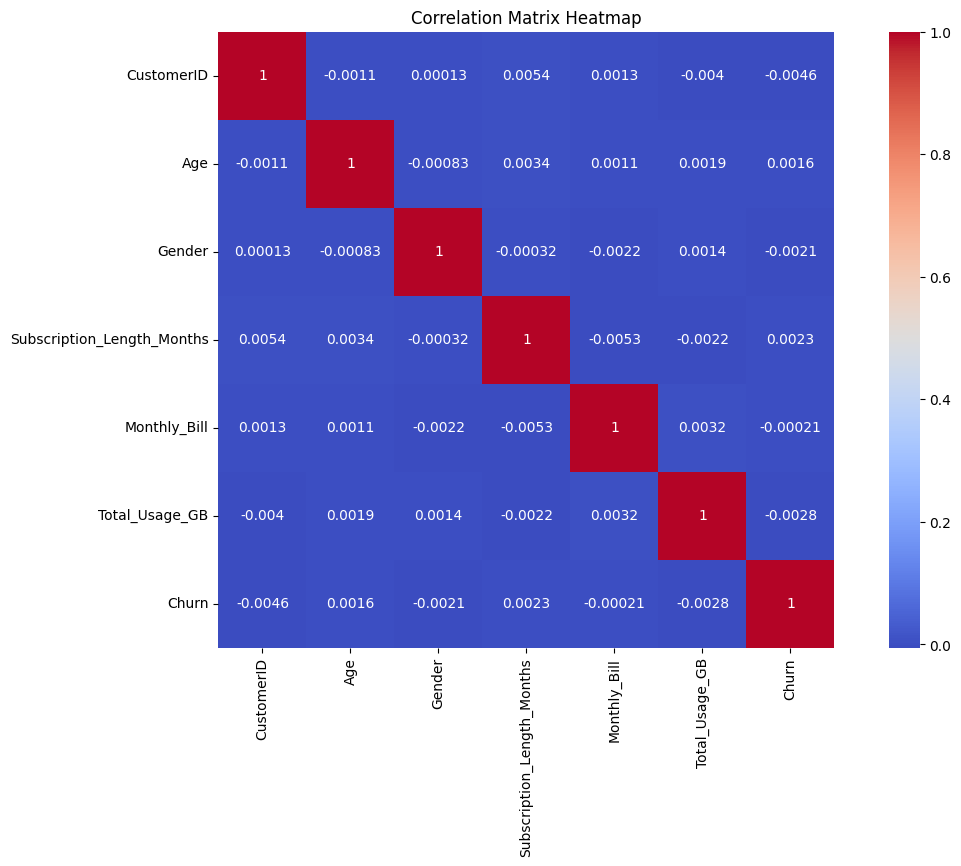

In [ ]:
#checking colinearity between variables

plt.figure(figsize=(14,8)) #(width,height)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

**No pair of variable is highly corrleated.**

# `Diving data into train and test set` 

In [ ]:
x = df.drop("Churn",axis=1)     
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

**Take 70% data for training and 30% for testing.**

In [ ]:
X_train.shape, y_train.shape

((70000, 6), (70000,))

In [ ]:
X_test.shape, y_test.shape

((30000, 6), (30000,))

In [ ]:
df.head()

,CustomerID,Age,Gender,Subscription_Length_Months,Monthly_Bill,Total_Usage_GB,Churn
0,1,63,0,17,73.36,236,0
1,2,62,1,1,48.76,172,0
2,3,24,1,5,85.47,460,0
3,4,36,1,3,97.94,297,1
4,5,46,1,19,58.14,266,0


# `Checking for the class imbalance`

* In machine learning, it is important to check if the data is balanced or not. This is called class imbalance.


* Class imbalance happens when there are more data points in one class than in the other class. This can affect the performance of the model.

In [ ]:
class_counts = df['Churn'].value_counts()
class_counts

Churn
0    50221
1    49779
Name: count, dtype: int64

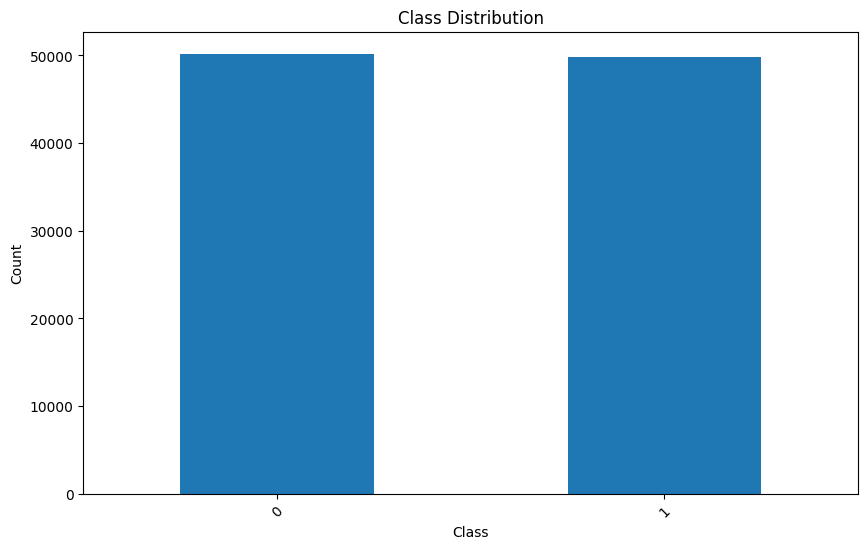

In [ ]:
plt.figure(figsize=(10, 6)) 
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**The churn variables are almost evenly distributed, which means that there is no problem of class imbalance.**

# `Checking multi-colinearity between variables`

* Multicollinearity can cause problems with the model, such as making it unstable and difficult to interpret. This is because correlated variables are redundant, meaning that they provide the same information. This can cause the model to give too much importance to one variable, leading to overfitting.

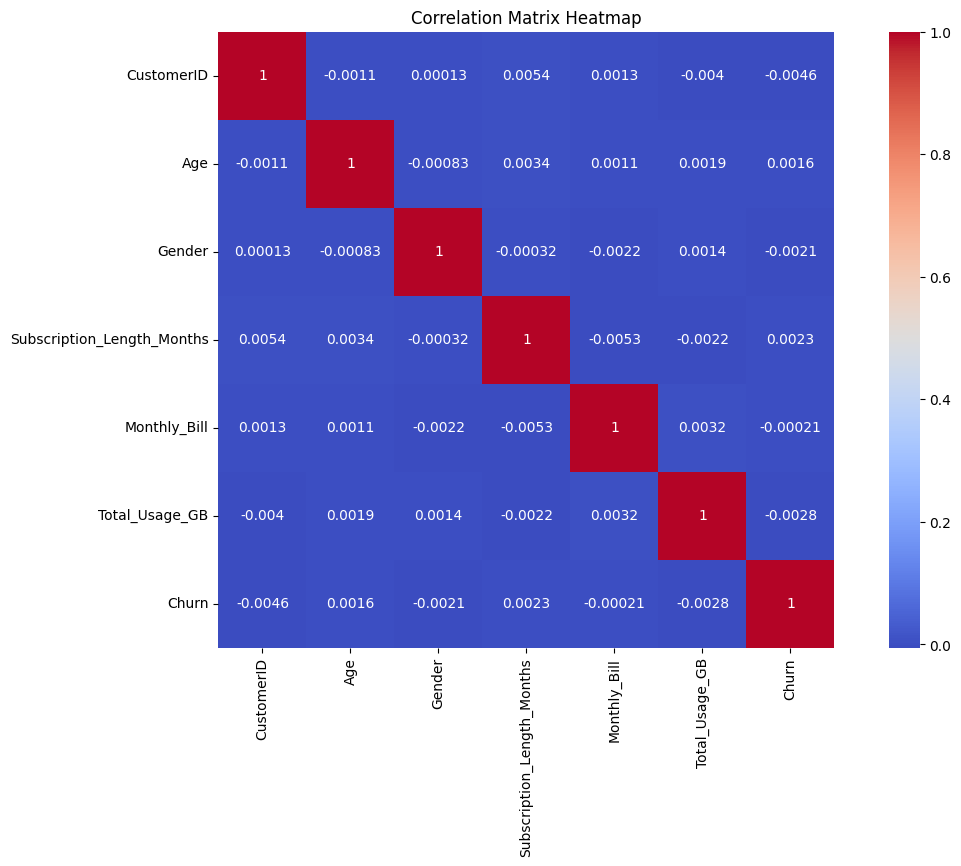

In [102]:
#checking colinearity between variables

corr_matrix = df.corr()

plt.figure(figsize=(14,8)) #(width,height)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

# `Model Building -- Algorithms`

In [103]:
#importing algorithms, metrics and time

import time

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

In [104]:
algorithms = [
    LogisticRegression(n_jobs=-1, random_state=42),
    DecisionTreeClassifier(random_state=42),
    KNeighborsClassifier(n_jobs=-1),
    GradientBoostingClassifier(random_state=42),
    RandomForestClassifier(n_jobs=-1, random_state=42),
]



In [ ]:
# Initialize the results dictionary for training data
results = {
    'Algorithm': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-score': [],
    'Building Time (s)': []
}

# Apply the algorithms and calculate performance metrics for training data
for algorithm in algorithms:
    start_time = time.time()  # Start timer

    algorithm_name = type(algorithm).__name__
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)

    accuracy = accuracy_score(y_train, y_train_pred)
    precision = precision_score(y_train, y_train_pred, average='weighted')
    recall = recall_score(y_train, y_train_pred, average='weighted')
    f1 = f1_score(y_train, y_train_pred, average='weighted')

    end_time = time.time()
    building_time = end_time - start_time

    results['Algorithm'].append(algorithm_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1-score'].append(f1)
    results['Building Time (s)'].append(building_time)

# Create a dataframe for the training data results
df_train = pd.DataFrame()
df_train

,Algorithm,Accuracy,Precision,Recall,F1-score,Building Time (s)
0,LogisticRegression,0.503129,0.503062,0.503129,0.496848,4.890076
1,DecisionTreeClassifier,1.000000,1.000000,1.000000,1.000000,0.989022
2,KNeighborsClassifier,0.688500,0.688500,0.688500,0.688498,0.600652
3,GradientBoostingClassifier,0.538557,0.538573,0.538557,0.538399,7.821525
4,RandomForestClassifier,1.000000,1.000000,1.000000,1.000000,4.909600


In [3]:
model.save('customer_churn_model.h5')

NameError: name 'model' is not defined

* **Decision Tree, Random Forest, and achieved perfect accuracy on the training data, suggesting potential overfitting.**

* **Logistic Regression, and Gradient Boosting have relatively low accuracy and F1-score.**

* **KNeighborsClassifier has moderate accuracy and F1-score.**


# `Outcome`

**The outcome of this customer churn prediction project involves developing a machine learning model to predict whether customers are likely to leave or not. This prediction is based on various customer attributes such as age, gender, location, subscription length, monthly bill, and total usage. The model's primary purpose is to assist in identifying customers who are at a higher risk of churning, enabling the business to take proactive measures to retain them. By using the trained model to predict churn, the company can allocate resources more effectively, personalize engagement strategies, and implement targeted retention efforts. Ultimately, the project's success is measured by the model's ability to make predictions, helping the company reduce churn rates, improve customer satisfaction, and optimize its customer retention strategies.**